In [ ]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [9]:
import numpy as np
from data import helpers, plotting
from data.prepare import extraction, augmentation, pruning, load

signal = helpers.load_processed_capnostream()["co2_wave"].to_numpy()

Extraction

In [ ]:
unit_markers = extraction.extract_unit_markers(signal)
unit_signals = [signal[start:end] for start, end in unit_markers]
print(f"Extracted {len(unit_signals)} unit signals.")

Pruning

In [14]:
# pruning random units (used for 'abnormal' testing set)
abnormal_signals = load.abnormal(with_pruning=False)
abnormal_signal_key = pruning.hash_array(abnormal_signals)
pruning.export_plots(signals=abnormal_signals, key=abnormal_signal_key, max=200)
pruning.build_mask(key=abnormal_signal_key)

Plots for key '2c5a1d4c5976d238b91f9c61038ace7fbed0d6a1f9b805c265a64f9c14b1354c' already exist at '/Users/paulb/Desktop/code/research/babi/data/prepare/pruning/raw/2c5a1d4c5976d238b91f9c61038ace7fbed0d6a1f9b805c265a64f9c14b1354c'. Skipping export.


In [ ]:
# pruning extracted data (used for training set)
stretched_signals = [augmentation.stretch_to_unit_length(us)[0] for us in unit_signals]
normative_signals = np.expand_dims(np.vstack(stretched_signals), axis=-1)
print(f"Before pruning, {len(normative_signals)} units remain for training dataset.")
normative_signals = pruning.apply_mask(normative_signals, key=pruning.hash_array(normative_signals))
print(f"After pruning, {len(normative_signals)} units remain for training dataset.")

Before pruning, 1778 units remain for training dataset.
After pruning, 1620 units remain for training dataset.


Augmentation

Augmentation type: raw


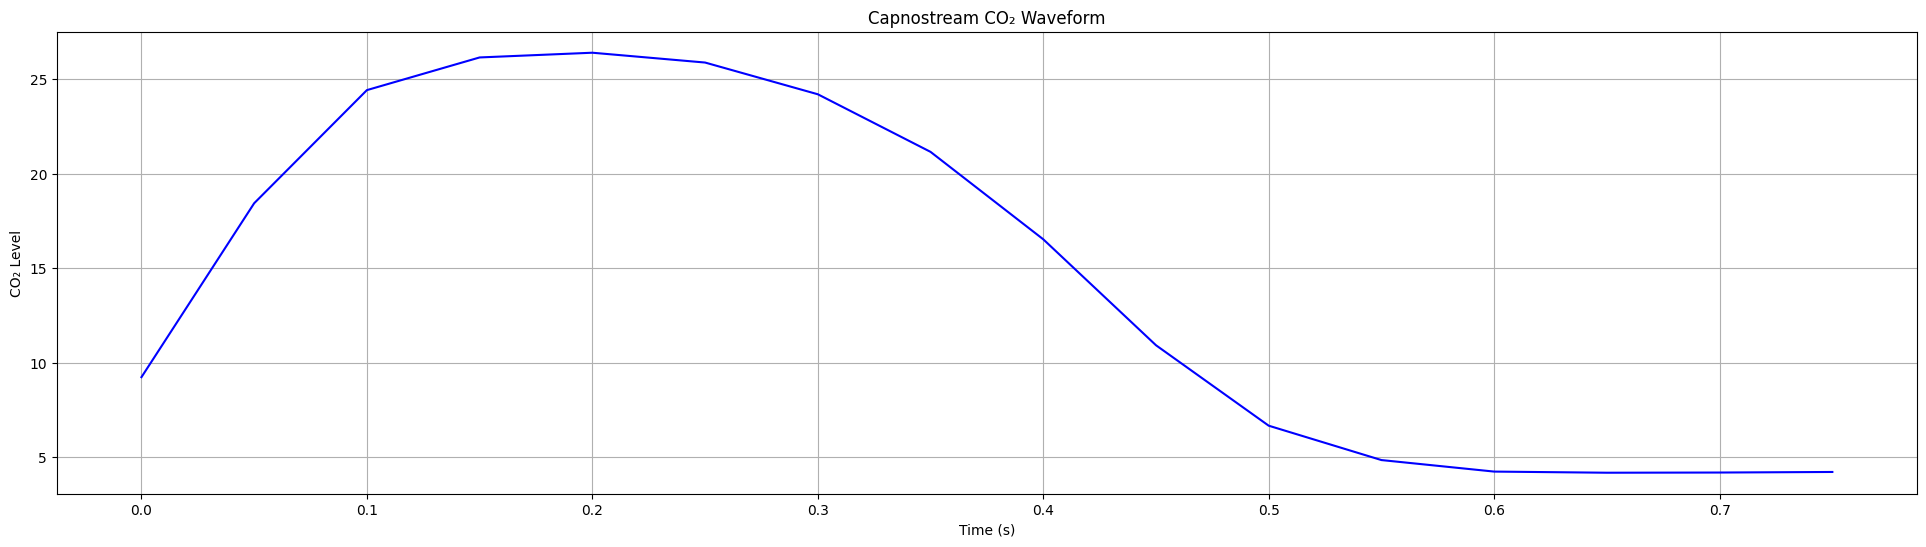

Augmentation type: scale


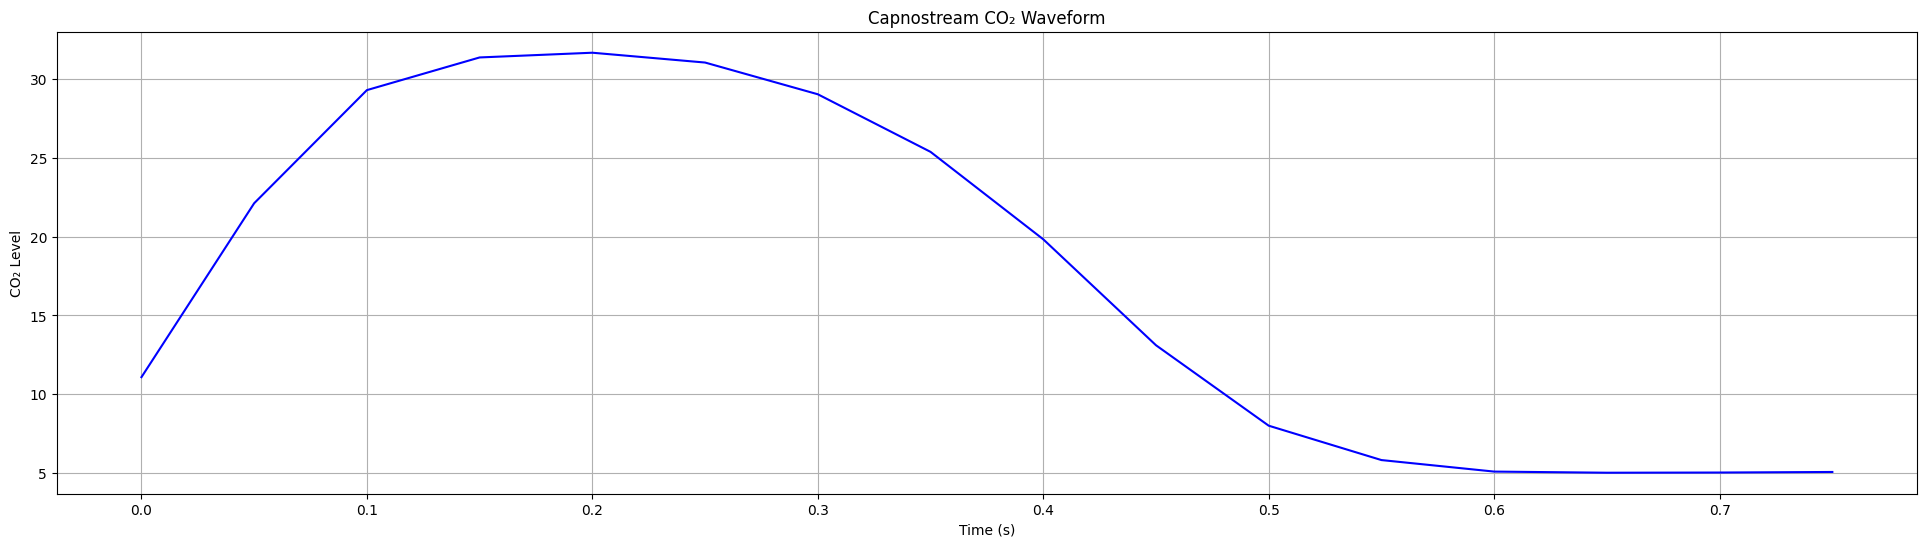

Augmentation type: roll


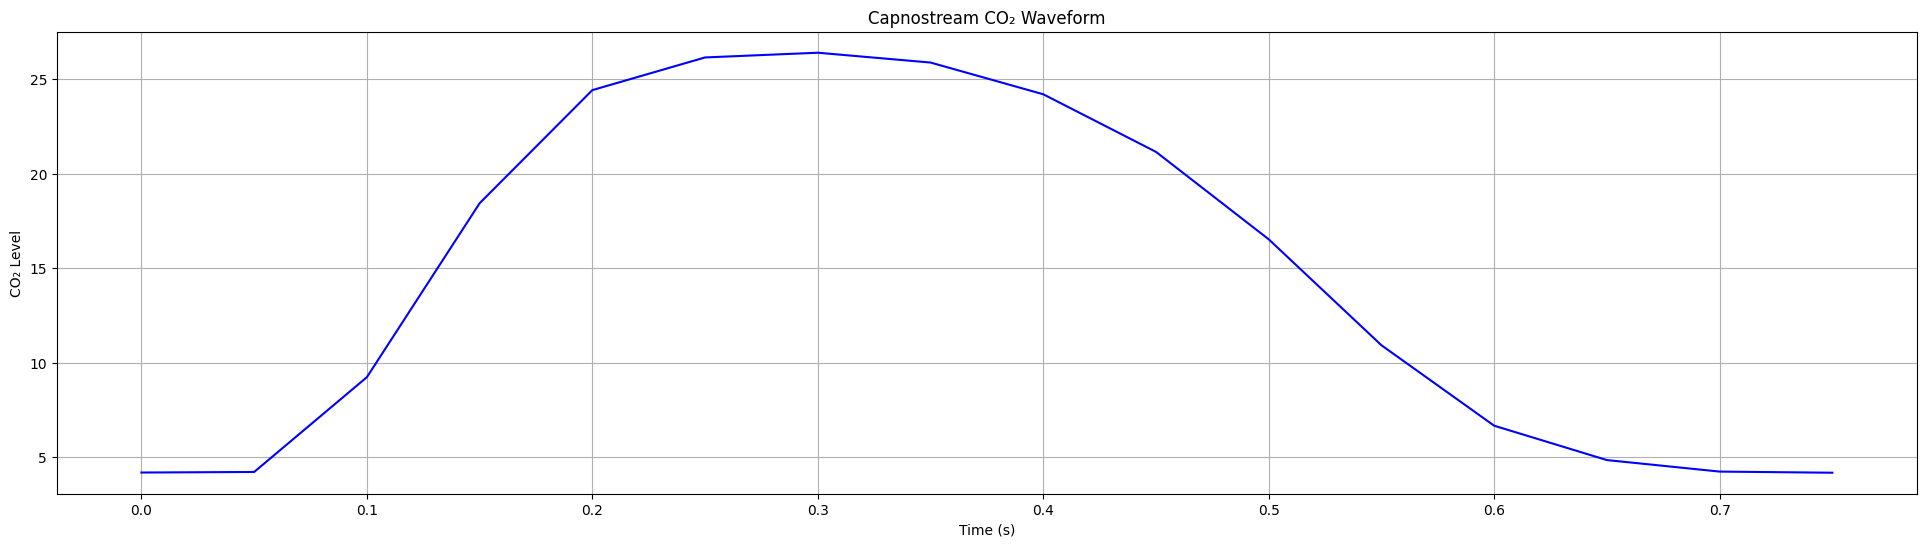

Augmentation type: noise


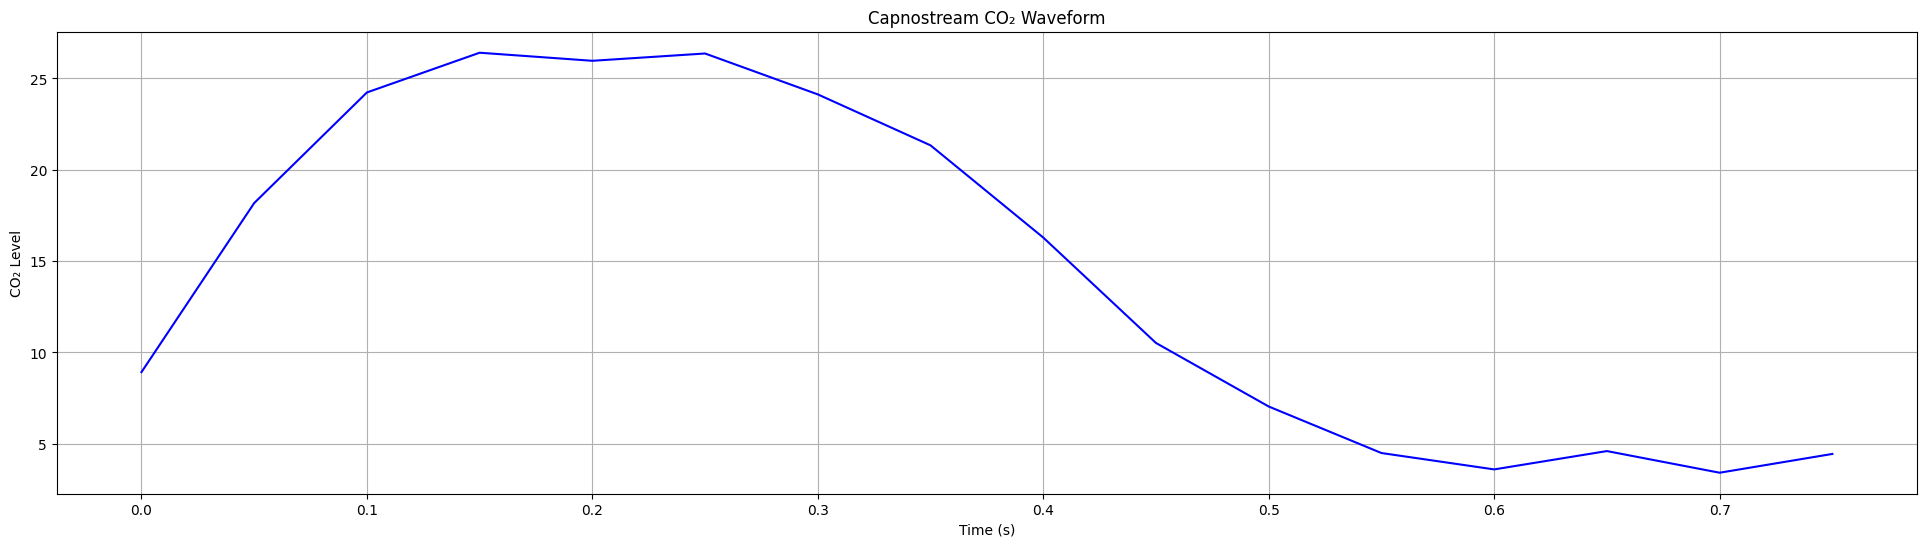

Augmentation type: stretch-wide


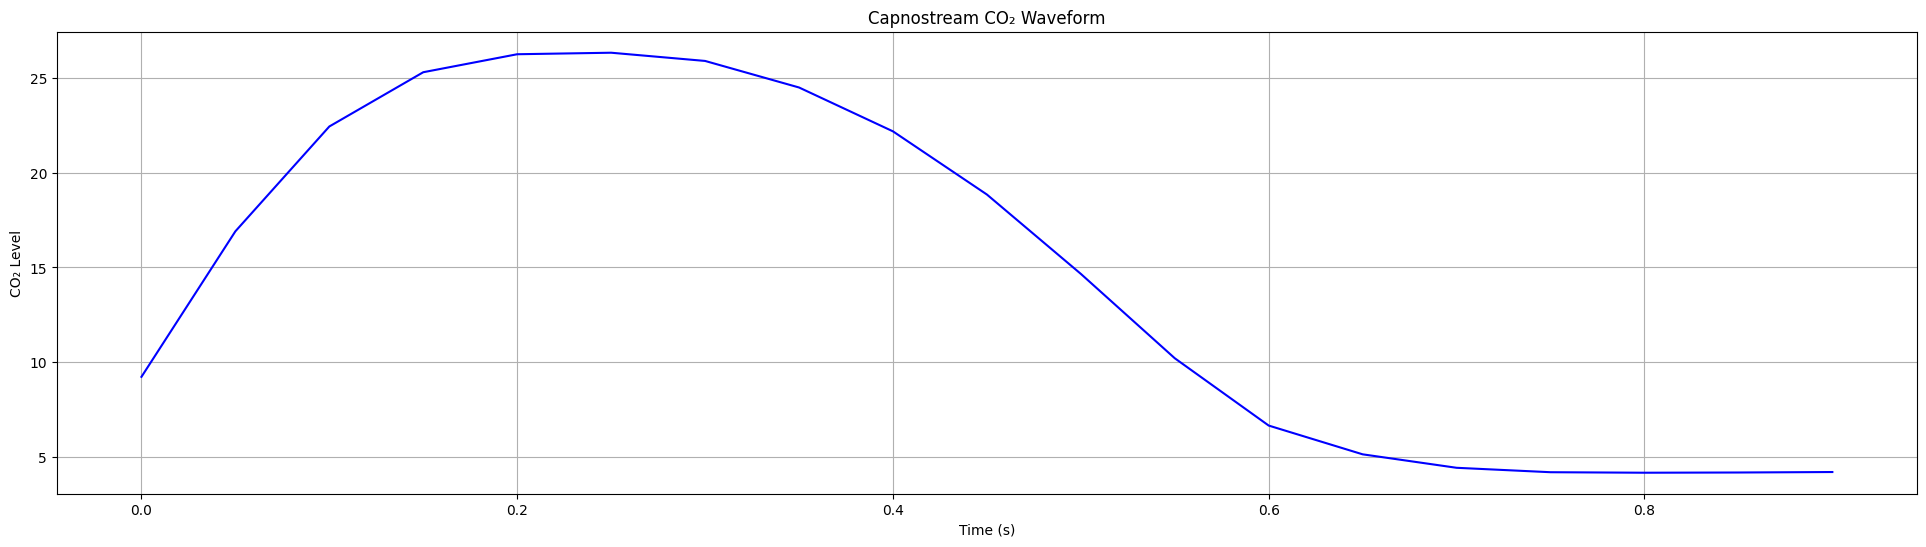

Augmentation type: stretch-narrow


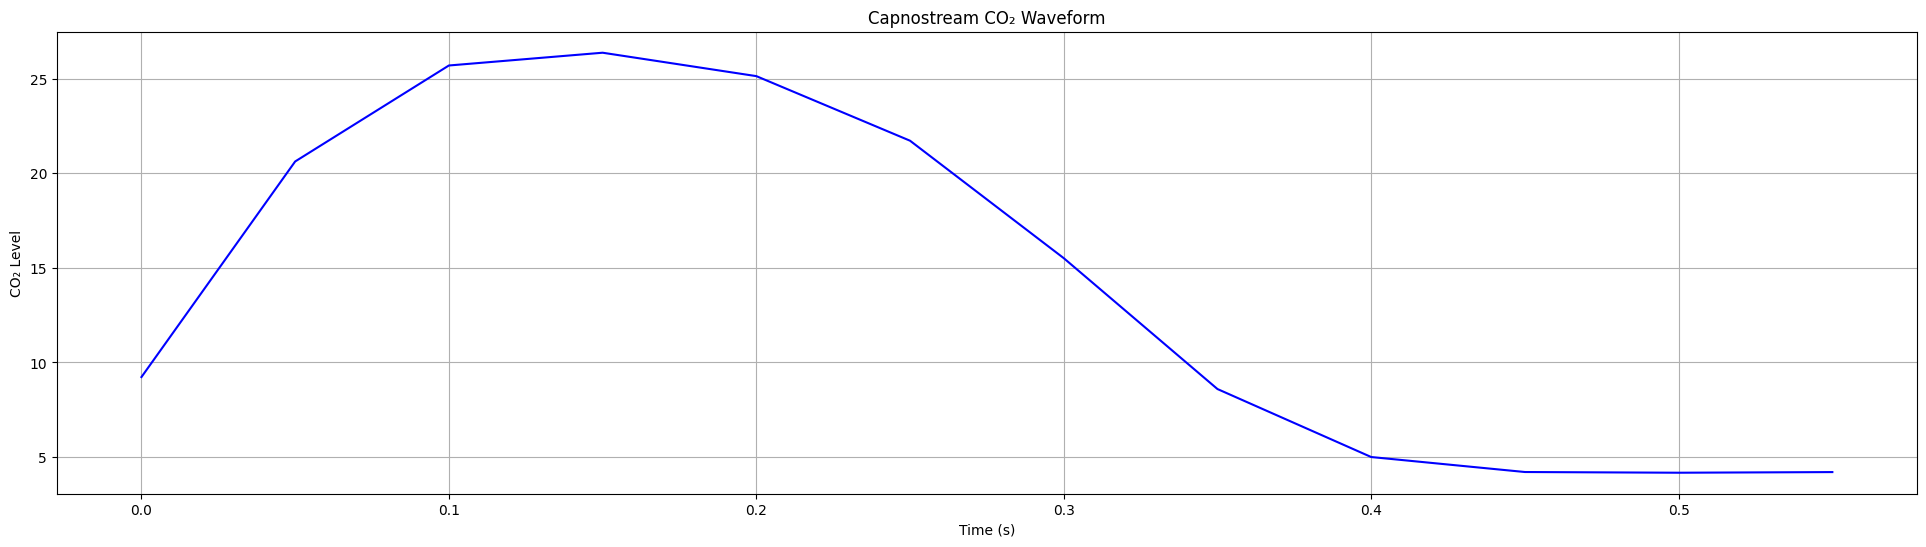

Augmentation type: all


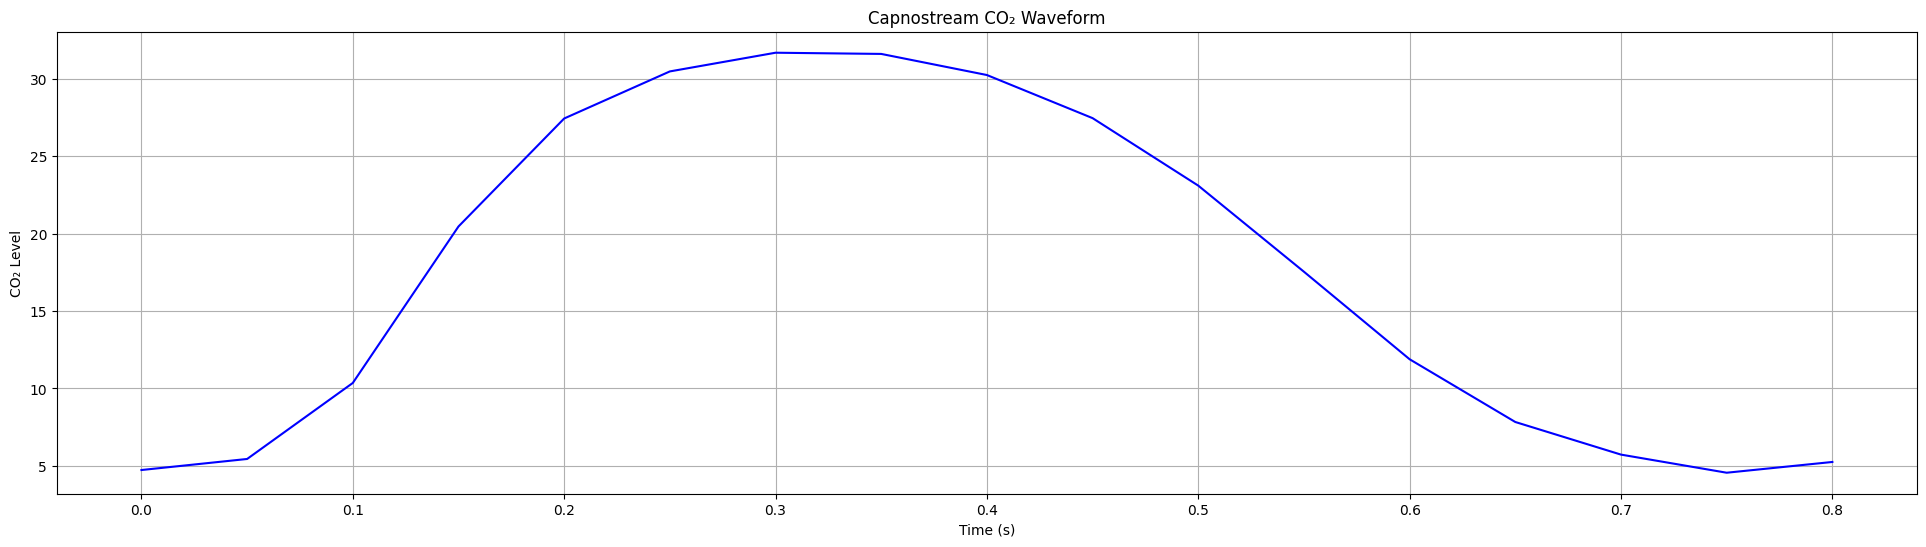

In [4]:
from data.prepare import augmentation

raw_signal = unit_signals[0]

augmented_signals = {
    "raw": raw_signal,
    "scale": augmentation.scale(raw_signal, scale_factor=1.2),
    "roll": augmentation.roll(raw_signal, roll_amount=2),
    "noise": augmentation.noise(raw_signal, noise_level=0.4),
    "stretch-wide": augmentation.stretch(raw_signal, stretch_factor=1.2),
    "stretch-narrow": augmentation.stretch(raw_signal, stretch_factor=0.8),
    "all": augmentation.stretch(augmentation.noise(augmentation.scale(augmentation.roll(raw_signal, roll_amount=2), scale_factor=1.2), noise_level=0.4), stretch_factor=1.1),
}

for aug_type, aug_signal in augmented_signals.items():
    print(f"Augmentation type: {aug_type}")
    plotting.plot_capnostream_waveform(data=aug_signal)